# Laboratorio 1 - Preparación de un corpus y EDA 
## Gian Paolo Robelo - 20230117

**Natural Language Processing** 

## Objetivos

En este laboratorio se realiza la preparación de un corpus de noticias en español y un análisis exploratorio de datos (EDA).  
Primero se explora el corpus, luego se aplica un pipeline de normalización y finalmente se analizan sus propiedades léxicas y distribuciones.

El corpus utilizado corresponde a noticias reales en español organizadas por categoría.

In [23]:
import re
import string
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Descargas necesarias
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

# Para mostrar tablas
from IPython.display import display

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gianp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\gianp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gianp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 1. Carga del corpus

En esta sección se carga el archivo `df_total.csv`, que contiene el texto de las noticias y su categoría.

In [24]:
# ==========================
# Carga del corpus
# ==========================

df = pd.read_csv("df_total.csv")

print("Forma del dataset:")
print(df.shape)

display(df.head())

Forma del dataset:
(1217, 3)


,url,news,Type
0,https://www.larepublica.co/redirect/post/3201905,Durante el foro La banca articulador empresari...,Otra
1,https://www.larepublica.co/redirect/post/3210288,El regulador de valores de China dijo el domin...,Regulaciones
2,https://www.larepublica.co/redirect/post/3240676,En una industria históricamente masculina como...,Alianzas
3,https://www.larepublica.co/redirect/post/3342889,Con el dato de marzo el IPC interanual encaden...,Macroeconomia
4,https://www.larepublica.co/redirect/post/3427208,Ayer en Cartagena se dio inicio a la versión n...,Otra


## 2. Exploración inicial del corpus

Antes de modificar el corpus, se revisa su estructura para responder:

- **¿Cuántos documentos tiene?**  
1217
- **¿Qué columnas contiene?**  
url, news, Type
- **¿Cuántas categorías hay y cómo se distribuyen?**  
7 categorías:   

| Type | Count |
| :--- | :--- |
| Macroeconomia | 340 |
| Alianzas | 247 |
| Innovacion | 195 |
| Regulaciones | 142 |
| Sostenibilidad | 137 |
| Otra | 130 |
| Reputacion | 26 |

- **¿Existen valores vacíos o duplicados?**  
No hay valores nulos, pero sí hay valores duplicados.

In [25]:
print("Número de documentos:", len(df))

print("\nColumnas del dataset:")
print(df.columns.tolist())

print("\nValores nulos:")
display(df.isnull().sum())

print("\nDuplicados completos:", df.duplicated().sum())

print("Duplicados únicamente en la noticia:")
print(df["news"].duplicated().sum())

print("\nNúmero de categorías:")
print(df["Type"].nunique())

display(df["Type"].value_counts())

Número de documentos: 1217

Columnas del dataset:
['url', 'news', 'Type']

Valores nulos:


url     0
news    0
Type    0
dtype: int64


Duplicados completos: 75
Duplicados únicamente en la noticia:
79

Número de categorías:
7


Type
Macroeconomia     340
Alianzas          247
Innovacion        195
Regulaciones      142
Sostenibilidad    137
Otra              130
Reputacion         26
Name: count, dtype: int64

## 3. Limpieza básica del corpus

Antes de aplicar la normalización, se eliminan espacios en blanco, textos vacíos y duplicados.  
Esto evita que el análisis posterior se vea afectado por documentos repetidos o sin contenido.

In [26]:

# Limpieza inicial


# Eliminar espacios
df["news"] = df["news"].astype(str).str.strip()
df["Type"] = df["Type"].astype(str).str.strip()

# Eliminar noticias vacías
df = df[df["news"] != ""].copy()

# Eliminar noticias duplicadas
df = df.drop_duplicates(subset=["news"]).reset_index(drop=True)

print("Cantidad de documentos después de limpiar:", len(df))

Cantidad de documentos después de limpiar: 1137


## 4. Funciones

Se definen funciones para tokenizar, pasar a minúsculas, eliminar puntuación, quitar stopwords y lematizar.  

In [27]:
# conjunto de stopwords en español para eliminar, son poco informativas
SPANISH_STOPWORDS = set(stopwords.words("spanish"))

# conjunto de signos de puntuación que se eliminarán del corpus
PUNCT = set(string.punctuation)
PUNCT.update({"¿","¡","«","»","“","”","‘","’","…","—","–"})

# se divide un texto en una lista de tokens
def tokenize(text):
    return word_tokenize(text, language="spanish")

# convierte todos los tokens a minúsculas
def lowercase(tokens):
    return [t.lower() for t in tokens]

# elimina signos de puntuación y otros caracteres que no sea alfanuméricos
def remove_punctuation(tokens):
    clean = []
    for token in tokens:
        if token in PUNCT: # ignora los signos de puntuación
            continue
        if re.fullmatch(r"[\W_]+", token): # ignora caracteres especiales
            continue
        clean.append(token)
    return clean # retorna sin singos de puntuación y caracteres especiales

# elimina los stopwords del conjunto de tokens
def remove_stopwords(tokens):
    return [t for t in tokens if t not in SPANISH_STOPWORDS]

In [28]:
# Lematización 

try:
    import spacy

    try:
        # modelo para realizar la lematización
        nlp = spacy.load("es_core_news_sm")

    except:

        print("No está instalado el modelo de español.")
        print("Ejecuta:")
        print("python -m spacy download es_core_news_sm")

        nlp = None

except:

    print("spaCy no está instalado.")
    nlp = None

# reduce cada palabra a su forma base (lema)
def lemmatize(tokens):

    if nlp is None:
        return tokens

    # convierte la lista de tokens en texto
    doc = nlp(" ".join(tokens))

    # obtiene el lema de cada topken y elimina vacíos
    return [tok.lemma_.lower() for tok in doc if tok.lemma_.strip() != ""]

In [29]:
# convierte una lista de listas en un única lista
def flatten(list_of_lists):

    return [word for doc in list_of_lists for word in doc]

# número total de tokens y tipos
def corpus_stats(documents):

    words = flatten(documents)

    return {
        "tokens": len(words), # número total de palabras
        "types": len(set(words)) # número de palabras distintas
    }

In [30]:
# Tokenización
df["tokens_1"] = df["news"].apply(tokenize)

# Minúsculas
df["tokens_2"] = df["tokens_1"].apply(lowercase)

# Eliminar puntuación
df["tokens_3"] = df["tokens_2"].apply(remove_punctuation)

# Eliminar stopwords
df["tokens_4"] = df["tokens_3"].apply(remove_stopwords)

# Lematización
df["tokens_5"] = df["tokens_4"].apply(lemmatize)

## 5. Pipeline de normalización

Se aplica el pipeline solicitado en este orden:

1. Tokenización  
2. Minúsculas  
3. Eliminación de puntuación  
4. Eliminación de stopwords  
5. Lematización  

Después de cada paso se contabilizan tokens y tipos.

In [31]:

# agrupar etapas para pipeline
pipeline = {
    "Tokenización": df["tokens_1"],
    "Minúsculas": df["tokens_2"],
    "Sin puntuación": df["tokens_3"],
    "Sin stopwords": df["tokens_4"],
    "Lematización": df["tokens_5"]
}

resultado = []

# calcula el número de tokens y tipos en cada etapa del pipeline
for etapa, docs in pipeline.items():

    stats = corpus_stats(docs.tolist())

    resultado.append({

        "Etapa": etapa,
        "Tokens": stats["tokens"],
        "Tipos": stats["types"]

    })

# convertir resultados en un dataframe para visualizarlos
pipeline_df = pd.DataFrame(resultado)

display(pipeline_df)

,Etapa,Tokens,Tipos
0,Tokenización,631733,38947
1,Minúsculas,631733,36099
2,Sin puntuación,598368,36063
3,Sin stopwords,318944,35852
4,Lematización,319410,28804


## 5.1 Ejemplo del proceso de normalización

Para visualizar mejor el efecto del preprocesamiento, se muestra una noticia del corpus en cada etapa del pipeline.

In [32]:
# Muestra reproducible: principio, centro y final del corpus limpio
indices_ejemplo = [0, len(df) // 2, len(df) - 1]

# tabla para visualizar los efectos de cada etapa del pipeline
ejemplos_normalizacion = pd.DataFrame({
    "Documento": indices_ejemplo,
    "Texto original (primeros 180 caracteres)": [
        df.loc[i, "news"][:180] + ("..." if len(df.loc[i, "news"]) > 180 else "")
        for i in indices_ejemplo
    ],
    "1. Tokenización": [df.loc[i, "tokens_1"][:25] for i in indices_ejemplo],
    "2. Minúsculas": [df.loc[i, "tokens_2"][:25] for i in indices_ejemplo],
    "3. Sin puntuación": [df.loc[i, "tokens_3"][:25] for i in indices_ejemplo],
    "4. Sin stopwords": [df.loc[i, "tokens_4"][:25] for i in indices_ejemplo],
    "5. Lemas": [df.loc[i, "tokens_5"][:25] for i in indices_ejemplo],
})

# mostrar la tabla con textos largos
with pd.option_context("display.max_colwidth", 120):
    display(ejemplos_normalizacion)


,Documento,Texto original (primeros 180 caracteres),1. Tokenización,2. Minúsculas,3. Sin puntuación,4. Sin stopwords,5. Lemas
0,0,Durante el foro La banca articulador empresarial para el desarrollo sostenible el director de sostenibilidad y clien...,"[Durante, el, foro, La, banca, articulador, empresarial, para, el, desarrollo, sostenible, el, director, de, sosteni...","[durante, el, foro, la, banca, articulador, empresarial, para, el, desarrollo, sostenible, el, director, de, sosteni...","[durante, el, foro, la, banca, articulador, empresarial, para, el, desarrollo, sostenible, el, director, de, sosteni...","[foro, banca, articulador, empresarial, desarrollo, sostenible, director, sostenibilidad, clientes, globales, bbva, ...","[foro, banca, articulador, empresarial, desarrollo, sostenible, director, sostenibilidad, cliente, global, bbva, col..."
1,568,Esta semana en 'Futuro sostenible' hablamos de detergentes sostenibles. Puede que no lo sepas pero el detergente que...,"[Esta, semana, en, ', Futuro, sostenible, ', hablamos, de, detergentes, sostenibles, ., Puede, que, no, lo, sepas, p...","[esta, semana, en, ', futuro, sostenible, ', hablamos, de, detergentes, sostenibles, ., puede, que, no, lo, sepas, p...","[esta, semana, en, futuro, sostenible, hablamos, de, detergentes, sostenibles, puede, que, no, lo, sepas, pero, el, ...","[semana, futuro, sostenible, hablamos, detergentes, sostenibles, puede, sepas, detergente, usamos, lavar, ropa, máqu...","[semana, futuro, sostenible, hablar, detergente, sostenible, poder, sepa, detergente, usamos, lavar, ropa, máquín, c..."
2,1136,Casi entrando a la parte final de noviembre la época hace recordar que el penúltimo mes del año acostumbra a estar c...,"[Casi, entrando, a, la, parte, final, de, noviembre, la, época, hace, recordar, que, el, penúltimo, mes, del, año, a...","[casi, entrando, a, la, parte, final, de, noviembre, la, época, hace, recordar, que, el, penúltimo, mes, del, año, a...","[casi, entrando, a, la, parte, final, de, noviembre, la, época, hace, recordar, que, el, penúltimo, mes, del, año, a...","[casi, entrando, parte, final, noviembre, época, hace, recordar, penúltimo, mes, año, acostumbra, cargado, lanzamien...","[casi, entrar, parte, final, noviembre, época, hacer, recordar, penúltimo, mes, año, acostumbrar, cargado, lanzamien..."


In [33]:
# Conteos por etapa para los mismos documentos (sin truncar)
conteos_ejemplo = []
for i in indices_ejemplo:
    fila = {"Documento": i, "Categoría": df.loc[i, "Type"]}
    # calcular número de tokens después de cada etapa de normalización
    for numero, columna in enumerate(
        ["tokens_1", "tokens_2", "tokens_3", "tokens_4", "tokens_5"], start=1
    ):
        fila[f"Etapa {numero}"] = len(df.loc[i, columna])
    conteos_ejemplo.append(fila)

display(pd.DataFrame(conteos_ejemplo))


,Documento,Categoría,Etapa 1,Etapa 2,Etapa 3,Etapa 4,Etapa 5
0,0,Otra,227,227,221,110,110
1,568,Sostenibilidad,169,169,152,77,78
2,1136,Alianzas,404,404,401,203,203


## 6. Análisis exploratorio de datos (EDA)

Con el corpus ya normalizado, se analizan sus propiedades léxicas y distribucionales:

- tokens y tipos antes y después de normalizar
- reducción del vocabulario
- riqueza léxica
- frecuencias de palabras
- distribución de longitud de documentos
- ley de Zipf
- comparación entre categorías
- nube de palabras

In [34]:

# Tokens y tipos

# calcular estadísticas del corpus antes y después
stats_original = corpus_stats(df["tokens_1"].tolist())
stats_final = corpus_stats(df["tokens_5"].tolist())

# calcular porcentaje de reducción de los tipos (vocabulario)
reduccion = (
    (stats_original["types"] - stats_final["types"])
    / stats_original["types"]
) * 100

# crear una tabla comparando el corpus original con el normalizado
resumen = pd.DataFrame({
    "Corpus": ["Original", "Normalizado"],
    "Tokens": [stats_original["tokens"], stats_final["tokens"]],
    "Tipos": [stats_original["types"], stats_final["types"]]
})

display(resumen)

print(f"Reducción del vocabulario: {reduccion:.2f}%")

,Corpus,Tokens,Tipos
0,Original,631733,38947
1,Normalizado,319410,28804


Reducción del vocabulario: 26.04%


## 6.1 Comparación por categoría

Se comparan las palabras más frecuentes de al menos dos categorías distintas para observar diferencias en su vocabulario.

In [35]:
# calcular la riqueza léxica del corpus normalizado
stats_globales = corpus_stats(df["tokens_5"].tolist())
riqueza_global = stats_globales["types"] / stats_globales["tokens"]
print(f"Riqueza léxica global: {riqueza_global:.4f}")

# calcular la riqueza léxica para cada categoría del corpus

riqueza = []

for categoria, grupo in df.groupby("Type"):

    # obtener los docs a la categoría
    docs = grupo["tokens_5"].tolist()

    # calcular stats de la categoría
    stats = corpus_stats(docs)

    riqueza.append({

        "Categoría": categoria,
        "Tokens": stats["tokens"],
        "Tipos": stats["types"],
        "Riqueza Léxica": round(stats["types"] / stats["tokens"], 4)

    })

riqueza = pd.DataFrame(riqueza)

display(riqueza.sort_values("Riqueza Léxica", ascending=False))


Riqueza léxica global: 0.0902


,Categoría,Tokens,Tipos,Riqueza Léxica
5,Reputacion,7704,2702,0.3507
4,Regulaciones,37162,8032,0.2161
3,Otra,28357,5813,0.2050
0,Alianzas,48898,9956,0.2036
6,Sostenibilidad,53362,8255,0.1547
1,Innovacion,50682,7070,0.1395
2,Macroeconomia,93245,11895,0.1276


In [36]:
# contar la frecuencia de cada palabra en el corpus normalizado
frecuencias = Counter(flatten(df["tokens_5"].tolist()))

# las 20 palabras más frecuentes
top20 = pd.DataFrame(

    frecuencias.most_common(20),

    columns=["Palabra","Frecuencia"]

)

display(top20)

,Palabra,Frecuencia
0,poder,2398
1,bbva,2149
2,año,2022
3,banco,1463
4,país,1397
5,inflación,1348
6,empresa,1295
7,nuevo,1216
8,precio,1199
9,ser,1198


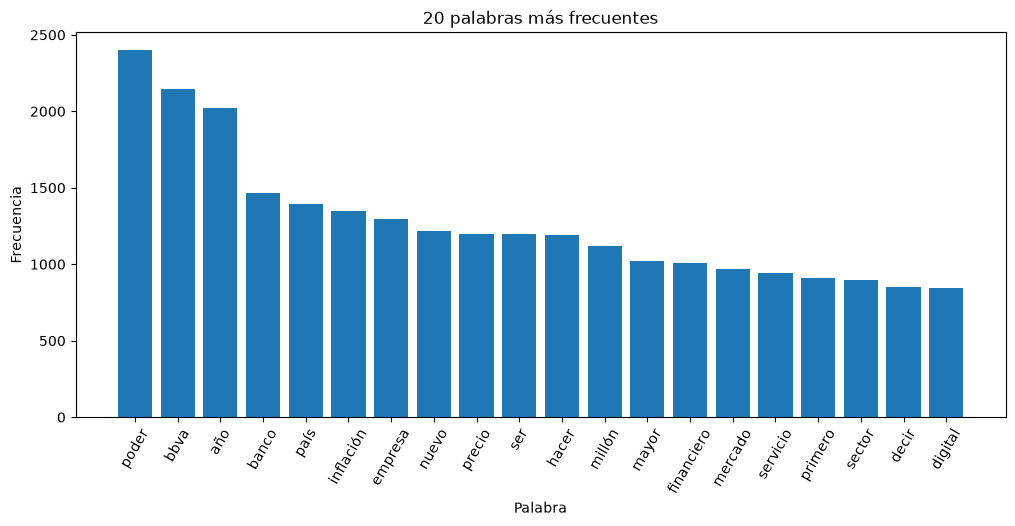

In [37]:
plt.figure(figsize=(12,5))

plt.bar(top20["Palabra"], top20["Frecuencia"])

plt.xticks(rotation=60)

plt.title("20 palabras más frecuentes")

plt.xlabel("Palabra")

plt.ylabel("Frecuencia")

plt.show()

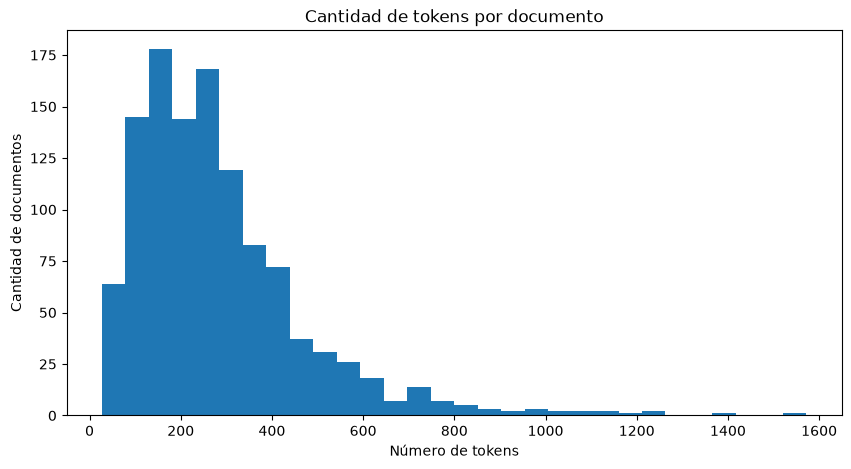

count    1137.000000
mean      280.923483
std       187.395920
min        27.000000
25%       150.000000
50%       245.000000
75%       353.000000
max      1572.000000
Name: tokens_5, dtype: float64

In [38]:
longitudes = df["tokens_5"].apply(len)

plt.figure(figsize=(10,5))

plt.hist(longitudes, bins=30)

plt.title("Cantidad de tokens por documento")

plt.xlabel("Número de tokens")

plt.ylabel("Cantidad de documentos")

plt.show()

display(longitudes.describe())

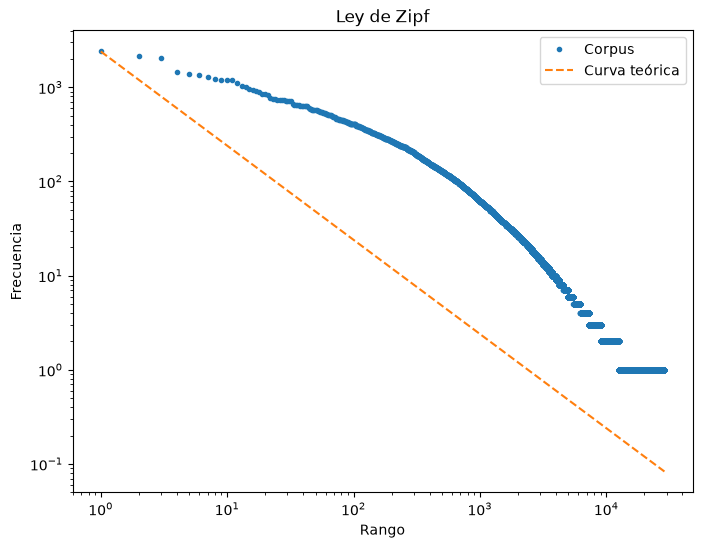

In [39]:
# ordenar las frecuencias de las palabras de mayor a menor
frecuencias_ordenadas = sorted(
    frecuencias.values(),
    reverse=True
)

# asignar un rango a cada palabra según su frecuencia
rangos = range(1, len(frecuencias_ordenadas)+1)

plt.figure(figsize=(8,6))

# graficar la distribución real del corpus en escala log-log
plt.loglog(
    rangos,
    frecuencias_ordenadas,
    marker='.',
    linestyle='none',
    label="Corpus"
)

# construir una curva teórica aproximada siguiendo la Ley de Zipf (k/r)
k = frecuencias_ordenadas[0]

zipf = [k/r for r in rangos]

# graficar la curva teórica para compararla con el corpus
plt.loglog(
    rangos,
    zipf,
    linestyle="--",
    label="Curva teórica"
)

plt.xlabel("Rango")
plt.ylabel("Frecuencia")
plt.title("Ley de Zipf")
plt.legend()
plt.show()

In [40]:
categorias = df["Type"].unique()

cat1 = categorias[0]
cat2 = categorias[1]

print("Categorías comparadas:")
print(cat1)
print(cat2)


def palabras_categoria(categoria):
    subset = df[df["Type"] == categoria]
    palabras = flatten(subset["tokens_5"].tolist())
    return Counter(palabras).most_common(10)


display(pd.DataFrame(
    palabras_categoria(cat1),
    columns=["Palabra","Frecuencia"]
))

display(pd.DataFrame(
    palabras_categoria(cat2),
    columns=["Palabra","Frecuencia"]
))

Categorías comparadas:
Otra
Regulaciones


,Palabra,Frecuencia
0,banco,386
1,bbva,332
2,millón,275
3,financiero,217
4,año,206
5,entidad,195
6,poder,164
7,crédito,157
8,cliente,142
9,tasa,139


,Palabra,Frecuencia
0,poder,275
1,decir,233
2,regulación,230
3,empresa,220
4,país,214
5,mercado,185
6,servicio,173
7,hacer,171
8,año,170
9,nuevo,168


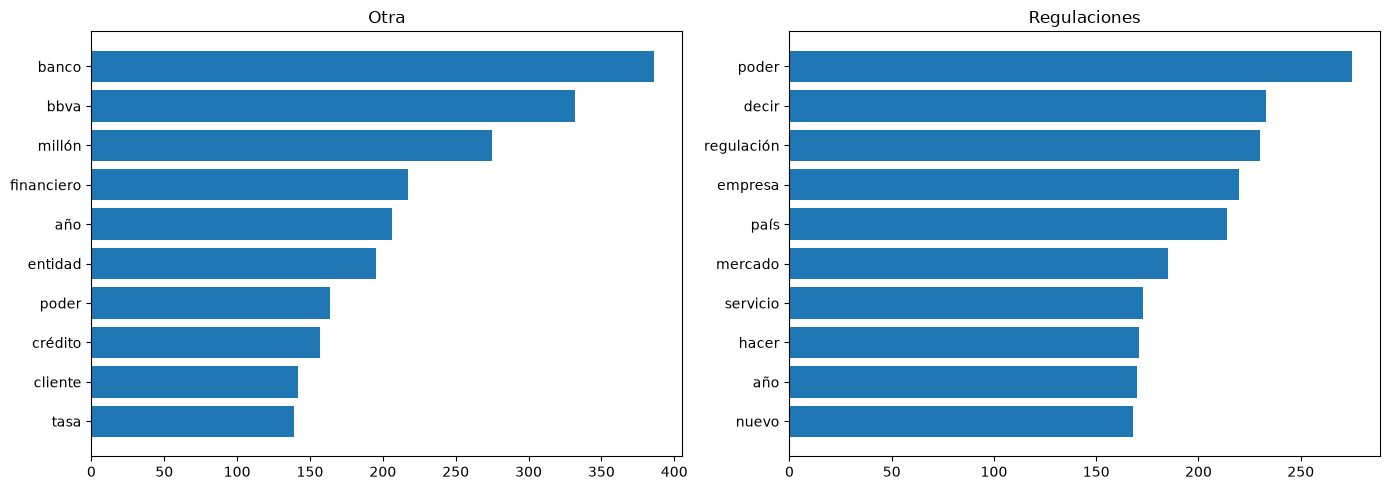

In [41]:
fig, ax = plt.subplots(1,2,figsize=(14,5))

for eje, categoria in zip(ax,[cat1,cat2]):
    datos = Counter(
        flatten(
            df[df["Type"]==categoria]["tokens_5"]
        )

    ).most_common(10)

    palabras = [x[0] for x in datos]
    frec = [x[1] for x in datos]
    eje.barh(palabras[::-1], frec[::-1])
    eje.set_title(categoria)

plt.tight_layout()
plt.show()

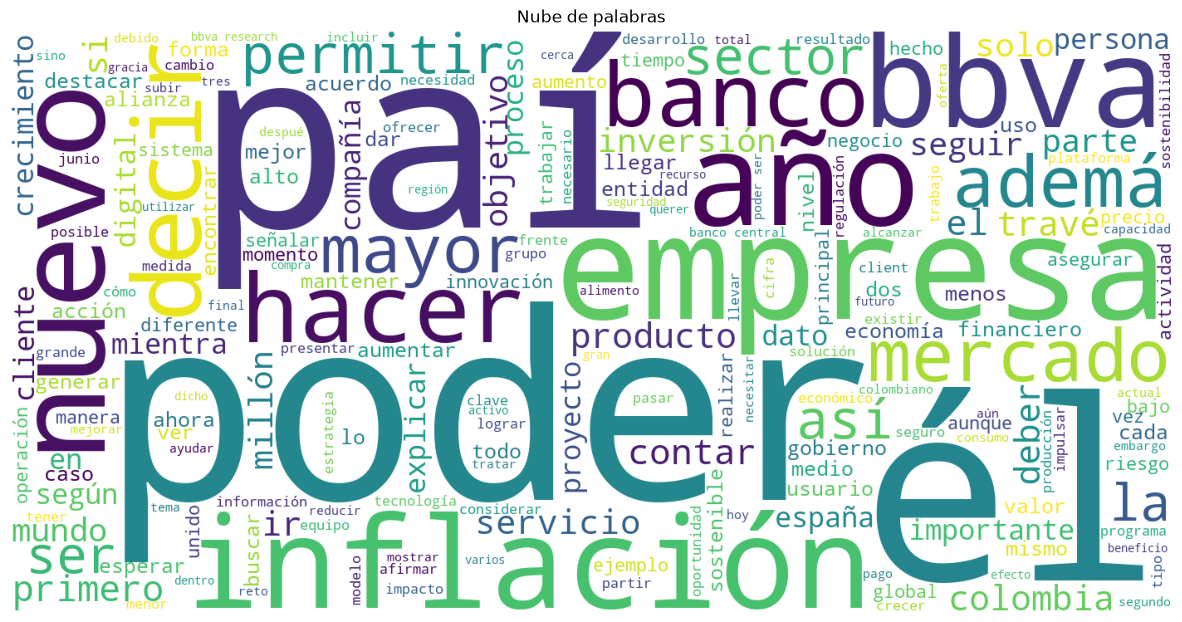

In [42]:
# intentar generar la nube de palabras del corpus normalizado
try:

    from wordcloud import WordCloud

    # unir todos los tokens normalizados en un solo texto
    texto = " ".join(flatten(df["tokens_5"].tolist()))

    # crear la nube de palabras
    nube = WordCloud(
        width=1400,
        height=700,
        background_color="white"
    ).generate(texto)

    # mostrar la nube de palabras
    plt.figure(figsize=(15,8))
    plt.imshow(nube)
    plt.axis("off")
    plt.title("Nube de palabras")
    plt.show()

except:

    print("Instala wordcloud con:")
    print("pip install wordcloud")

In [43]:

# Reducción del vocabulario por cada etapa

# calcular la reducción porcentual del vocabulario entre cada etapa del pipeline
tipos = pipeline_df["Tipos"].tolist()
etapas = pipeline_df["Etapa"].tolist()

reducciones = []

for i in range(len(tipos)):

    # la primera etapa es la referencia inicial, por lo que no tiene reducción
    if i == 0:
        reducciones.append(0)

    else:

        reduccion = (tipos[i-1]-tipos[i])/tipos[i-1]*100
        reducciones.append(round(reduccion,2))

# agregar la reducción porcentual al resumen del pipeline
pipeline_df["Reducción (%)"] = reducciones

display(pipeline_df)

,Etapa,Tokens,Tipos,Reducción (%)
0,Tokenización,631733,38947,0.00
1,Minúsculas,631733,36099,7.31
2,Sin puntuación,598368,36063,0.10
3,Sin stopwords,318944,35852,0.59
4,Lematización,319410,28804,19.66


## 7. Resumen y conclusiones

En esta sección se redactan las conclusiones finales del análisis y se responden las preguntas del laboratorio.

In [44]:
print("="*60)
print("RESUMEN DEL LABORATORIO")
print("="*60)

print("\nNúmero de documentos:", len(df))

print("\nNúmero de categorías:")
print(df["Type"].nunique())

print("\nDistribución de categorías:")
display(df["Type"].value_counts())

print("\nResumen del pipeline:")
display(pipeline_df)

print("\nResumen del EDA:")
display(resumen)

print("\nRiqueza léxica global:")
stats = corpus_stats(df["tokens_5"].tolist())
riqueza = stats["types"] / stats["tokens"]

print(round(riqueza, 4))

RESUMEN DEL LABORATORIO

Número de documentos: 1137

Número de categorías:
7

Distribución de categorías:


Type
Macroeconomia     319
Alianzas          246
Innovacion        152
Regulaciones      141
Otra              129
Sostenibilidad    124
Reputacion         26
Name: count, dtype: int64


Resumen del pipeline:


,Etapa,Tokens,Tipos,Reducción (%)
0,Tokenización,631733,38947,0.00
1,Minúsculas,631733,36099,7.31
2,Sin puntuación,598368,36063,0.10
3,Sin stopwords,318944,35852,0.59
4,Lematización,319410,28804,19.66



Resumen del EDA:


,Corpus,Tokens,Tipos
0,Original,631733,38947
1,Normalizado,319410,28804



Riqueza léxica global:
0.0902
